In [1]:
import os
import numpy as np
import tensorflow as tf
import sklearn
import cv2

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Sisanya gunakan dari keras standalone
from keras.models import Model
from keras.applications import EfficientNetB2
from keras.applications.efficientnet import preprocess_input
from keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from keras.optimizers import Adam


In [2]:
os.add_dll_directory("C:/Program Files/NVIDIA GPU Computing Toolkit/CUDA/v11.2/bin")
os.add_dll_directory("C:/Program Files/NVIDIA GPU Computing Toolkit/CUDA/v11.2/libnvvp")

<AddedDllDirectory('C:/Program Files/NVIDIA GPU Computing Toolkit/CUDA/v11.2/libnvvp')>

In [3]:
import tensorflow as tf
print(tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Menginstal paket Kaggle
!pip install kaggle -q

# Mengunduh dataset baru
!kaggle datasets download -d asdasdasasdas/garbage-classification

Dataset URL: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification
License(s): copyright-authors




  0%|          | 0.00/82.0M [00:00<?, ?B/s]
  1%|          | 1.00M/82.0M [00:00<01:12, 1.17MB/s]
  2%|▏         | 2.00M/82.0M [00:01<00:43, 1.94MB/s]
  4%|▎         | 3.00M/82.0M [00:01<00:34, 2.41MB/s]
  5%|▍         | 4.00M/82.0M [00:01<00:33, 2.45MB/s]
  6%|▌         | 5.00M/82.0M [00:02<00:33, 2.40MB/s]
  7%|▋         | 6.00M/82.0M [00:02<00:34, 2.32MB/s]
  9%|▊         | 7.00M/82.0M [00:03<00:35, 2.20MB/s]
 10%|▉         | 8.00M/82.0M [00:03<00:36, 2.15MB/s]
 11%|█         | 9.00M/82.0M [00:04<00:37, 2.04MB/s]
 12%|█▏        | 10.0M/82.0M [00:04<00:35, 2.14MB/s]
 13%|█▎        | 11.0M/82.0M [00:05<00:37, 1.97MB/s]
 15%|█▍        | 12.0M/82.0M [00:06<00:40, 1.83MB/s]
 16%|█▌        | 13.0M/82.0M [00:06<00:35, 2.06MB/s]
 17%|█▋        | 14.0M/82.0M [00:06<00:32, 2.19MB/s]
 18%|█▊        | 15.0M/82.0M [00:07<00:31, 2.21MB/s]
 20%|█▉        | 16.0M/82.0M [00:08<00:33, 2.05MB/s]
 21%|██        | 17.0M/82.0M [00:08<00:35, 1.90MB/s]
 22%|██▏       | 18.0M/82.0M [00:08<00:30, 2.20MB/s]
 

In [5]:
# Mengekstrak file zip yang diunduh
import zipfile
with zipfile.ZipFile('garbage-classification.zip', 'r') as zip_ref:
    zip_ref.extractall('garbage_data')

In [6]:
# Step 1: Prepare Dataset
dataset_path = "garbage_data/Garbage classification/Garbage classification"
classes = os.listdir(dataset_path)
print("Classes:", classes)

# Prepare the dataset paths and labels
image_paths, labels = [], []
for label, class_name in enumerate(classes):
    class_dir = os.path.join(dataset_path, class_name)
    for img_name in os.listdir(class_dir):
        image_paths.append(os.path.join(class_dir, img_name))
        labels.append(label)

# Create a DataFrame
import pandas as pd
data = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

# Split dataset
train_df, test_df = train_test_split(data, test_size=0.2, stratify=data['label'], random_state=42)

# Image preprocessing and augmentation
IMG_SIZE = 224
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img

def augment_image(img):
    # Example: Augmentations (flip, rotation)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.rot90(img)
    return img

# Step 2: Data Generators
def data_generator(data, batch_size=32, augment=False):
    while True:
        batch_data = data.sample(batch_size)
        batch_images, batch_labels = [], []
        for _, row in batch_data.iterrows():
            img = preprocess_image(row['image_path'])
            label = row['label']
            if augment:
                img = augment_image(img)
            batch_images.append(img)
            batch_labels.append(label)
        yield np.array(batch_images), np.array(batch_labels)

train_gen = data_generator(train_df, batch_size=32, augment=True)
test_gen = data_generator(test_df, batch_size=32)

# Step 3: Build Classification Model with EfficientNet-B2
base_model = EfficientNetB2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.5)(x)
output = Dense(len(classes), activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=output)

# Freeze the base model initially
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Step 4: Train the Model
history = model.fit(train_gen,
                    steps_per_epoch=len(train_df)//32,
                    validation_data=test_gen,
                    validation_steps=len(test_df)//32,
                    epochs=10)

# Step 5: Evaluate the Model
test_images, test_labels = next(test_gen)
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Epoch 1/10
63/63 [==============================] - 55s 646ms/step - loss: 1.1228 - accuracy: 0.5977 - val_loss: 0.7034 - val_accuracy: 0.7917
Epoch 2/10
63/63 [==============================] - 29s 467ms/step - loss: 0.5784 - accuracy: 0.8090 - val_loss: 0.5332 - val_accuracy: 0.8417
Epoch 3/10
63/63 [==============================] - 26s 413ms/step - loss: 0.5219 - accuracy: 0.8189 - val_loss: 0.4798 - val_accuracy: 0.8604
Epoch 4/10
63/63 [==============================] - 25s 395ms/step - loss: 0.4389 - accuracy: 0.8621 - val_loss: 0.4416 - val_accuracy: 0.8479
Epoch 5/10
63/63 [==============================] - 24s 388ms/step - loss: 0.4257 - accuracy: 0.8462 - val_loss: 0.3937 - val_accuracy: 0.8813
Epoch 6/10
63/63 [==============================] - 24s 382ms/step - loss: 0.3732 - accuracy: 0.8790 - val_loss: 0.3879 - val_accuracy: 0.8583
Epoch 7/10
63/63 [==============================] - 24s 392ms/step - los

In [7]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

# Ambil label unik
unique_labels = np.unique(test_labels)
label_names = [classes[i] for i in unique_labels]

# Classification Report
print("Classification Report:")
print(classification_report(test_labels, predicted_labels, target_names=label_names))

# Metric
precision, recall, f1, _ = precision_recall_fscore_support(test_labels, predicted_labels, average='weighted')
print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}")


Classification Report:
              precision    recall  f1-score   support

   cardboard       1.00      1.00      1.00         5
       glass       0.73      1.00      0.84         8
       metal       1.00      0.89      0.94         9
       paper       1.00      1.00      1.00         5
     plastic       1.00      0.60      0.75         5

    accuracy                           0.91        32
   macro avg       0.95      0.90      0.91        32
weighted avg       0.93      0.91      0.90        32

Precision: 0.93, Recall: 0.91, F1-Score: 0.90


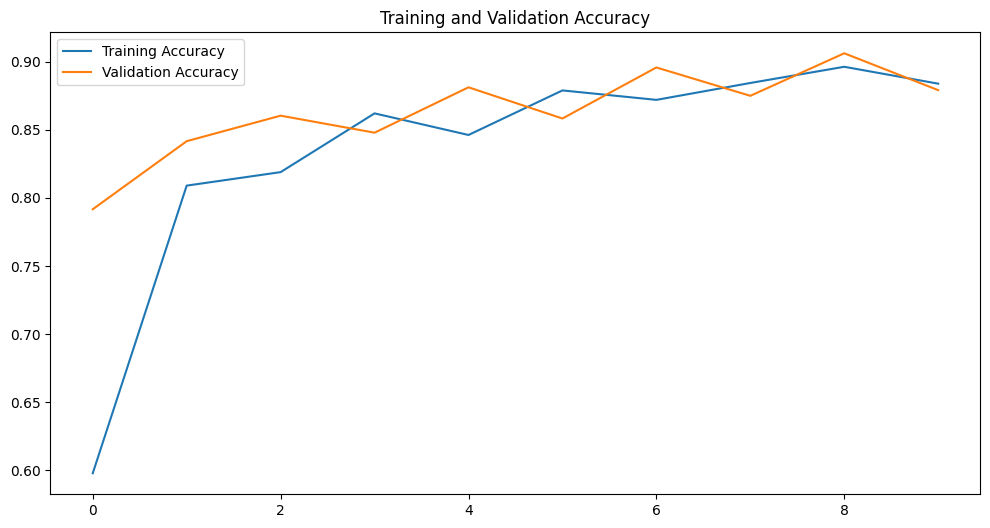

In [8]:
# Plot Training Accuracy and Loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

In [9]:
# Hyperparameter Adjustments
BATCH_SIZE = 64
IMG_SIZE = 224
EPOCHS = 15
INITIAL_LR = 0.0001
FINE_TUNE_LAYERS = 20
FINE_TUNE_LR = 0.0001
DROPOUT_RATE = 0.3

# Enhanced Augmentation: flip, rotate, brightness, contrast
def augment_image(img):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.rot90(img)  # <-- rotate
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    return img

# Data Generator Function
def data_generator(data, batch_size=BATCH_SIZE, augment=False):
    while True:
        batch_data = data.sample(batch_size)
        batch_images, batch_labels = [], []
        for _, row in batch_data.iterrows():
            img = preprocess_image(row['image_path'])
            if augment:
                img = augment_image(img)
            batch_images.append(img)
            batch_labels.append(row['label'])
        yield np.array(batch_images), np.array(batch_labels)

train_gen = data_generator(train_df, batch_size=BATCH_SIZE, augment=True)
test_gen = data_generator(test_df, batch_size=BATCH_SIZE)

# Load Pretrained EfficientNetB2 Model
base_model = EfficientNetB2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(DROPOUT_RATE)(x)
output = Dense(len(classes), activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=output)

# Freeze Base Model Layers
for layer in base_model.layers:
    layer.trainable = False

# Compile the Model
model.compile(optimizer=Adam(learning_rate=INITIAL_LR),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=2, min_lr=1e-6)
]

# Train the Model
history = model.fit(train_gen,
                    steps_per_epoch=len(train_df) // BATCH_SIZE,
                    validation_data=test_gen,
                    validation_steps=len(test_df) // BATCH_SIZE,
                    epochs=EPOCHS,
                    callbacks=callbacks)

# Fine-tuning: unfreeze last N layers
for layer in base_model.layers[-FINE_TUNE_LAYERS:]:
    layer.trainable = True

# Recompile with Fine-Tune Learning Rate
model.compile(optimizer=Adam(learning_rate=FINE_TUNE_LR),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Fine-Tune the Model
history_fine = model.fit(train_gen,
                         steps_per_epoch=len(train_df) // BATCH_SIZE,
                         validation_data=test_gen,
                         validation_steps=len(test_df) // BATCH_SIZE,
                         epochs=5,
                         callbacks=callbacks)

# Evaluate the Model
test_images, test_labels = next(test_gen)
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)


Epoch 1/15
31/31 [==============================] - 41s 1s/step - loss: 1.7763 - accuracy: 0.2490 - val_loss: 1.6098 - val_accuracy: 0.3996 - lr: 1.0000e-04
Epoch 2/15
31/31 [==============================] - 27s 908ms/step - loss: 1.6131 - accuracy: 0.3604 - val_loss: 1.4345 - val_accuracy: 0.5290 - lr: 1.0000e-04
Epoch 3/15
31/31 [==============================] - 28s 908ms/step - loss: 1.4385 - accuracy: 0.4758 - val_loss: 1.2990 - val_accuracy: 0.6004 - lr: 1.0000e-04
Epoch 4/15
31/31 [==============================] - 28s 912ms/step - loss: 1.3021 - accuracy: 0.5595 - val_loss: 1.2145 - val_accuracy: 0.6362 - lr: 1.0000e-04
Epoch 5/15
31/31 [==============================] - 28s 907ms/step - loss: 1.2077 - accuracy: 0.6190 - val_loss: 1.1225 - val_accuracy: 0.6674 - lr: 1.0000e-04
Epoch 6/15
31/31 [==============================] - 28s 905ms/step - loss: 1.1314 - accuracy: 0.6386 - val_loss: 1.0540 - val_accuracy: 0.6853 - lr: 1.0000e-04
Epoch 7/15
31/31 [=========================

In [10]:
# Classification Report
print("Classification Report:")
print(classification_report(test_labels, predicted_labels, target_names=classes))

Classification Report:
              precision    recall  f1-score   support

   cardboard       1.00      0.75      0.86         8
       glass       1.00      0.82      0.90        11
       metal       0.87      1.00      0.93        13
       paper       0.89      1.00      0.94        16
     plastic       0.92      0.86      0.89        14
       trash       0.33      0.50      0.40         2

    accuracy                           0.89        64
   macro avg       0.84      0.82      0.82        64
weighted avg       0.91      0.89      0.89        64



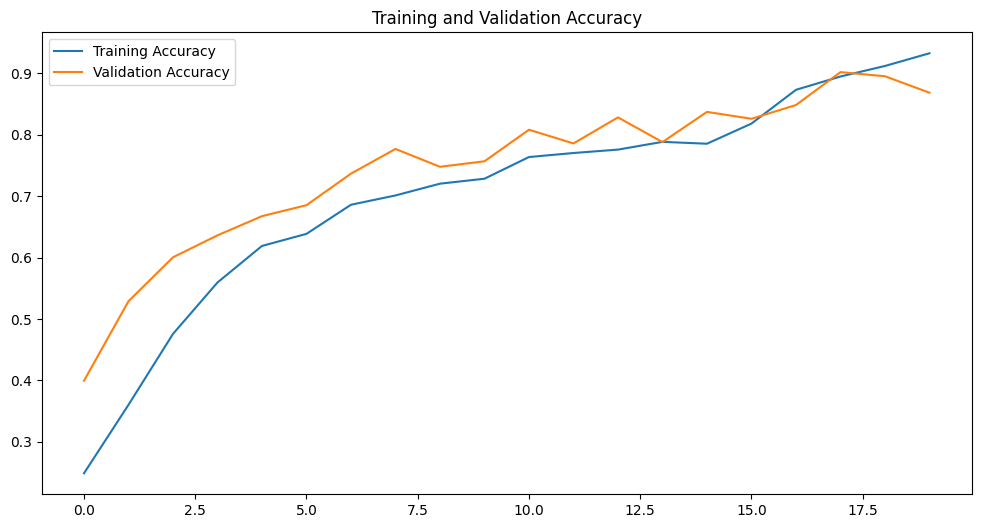

In [11]:

# Plot Training and Validation Metrics
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

2/2 [==============================] - 0s 122ms/step


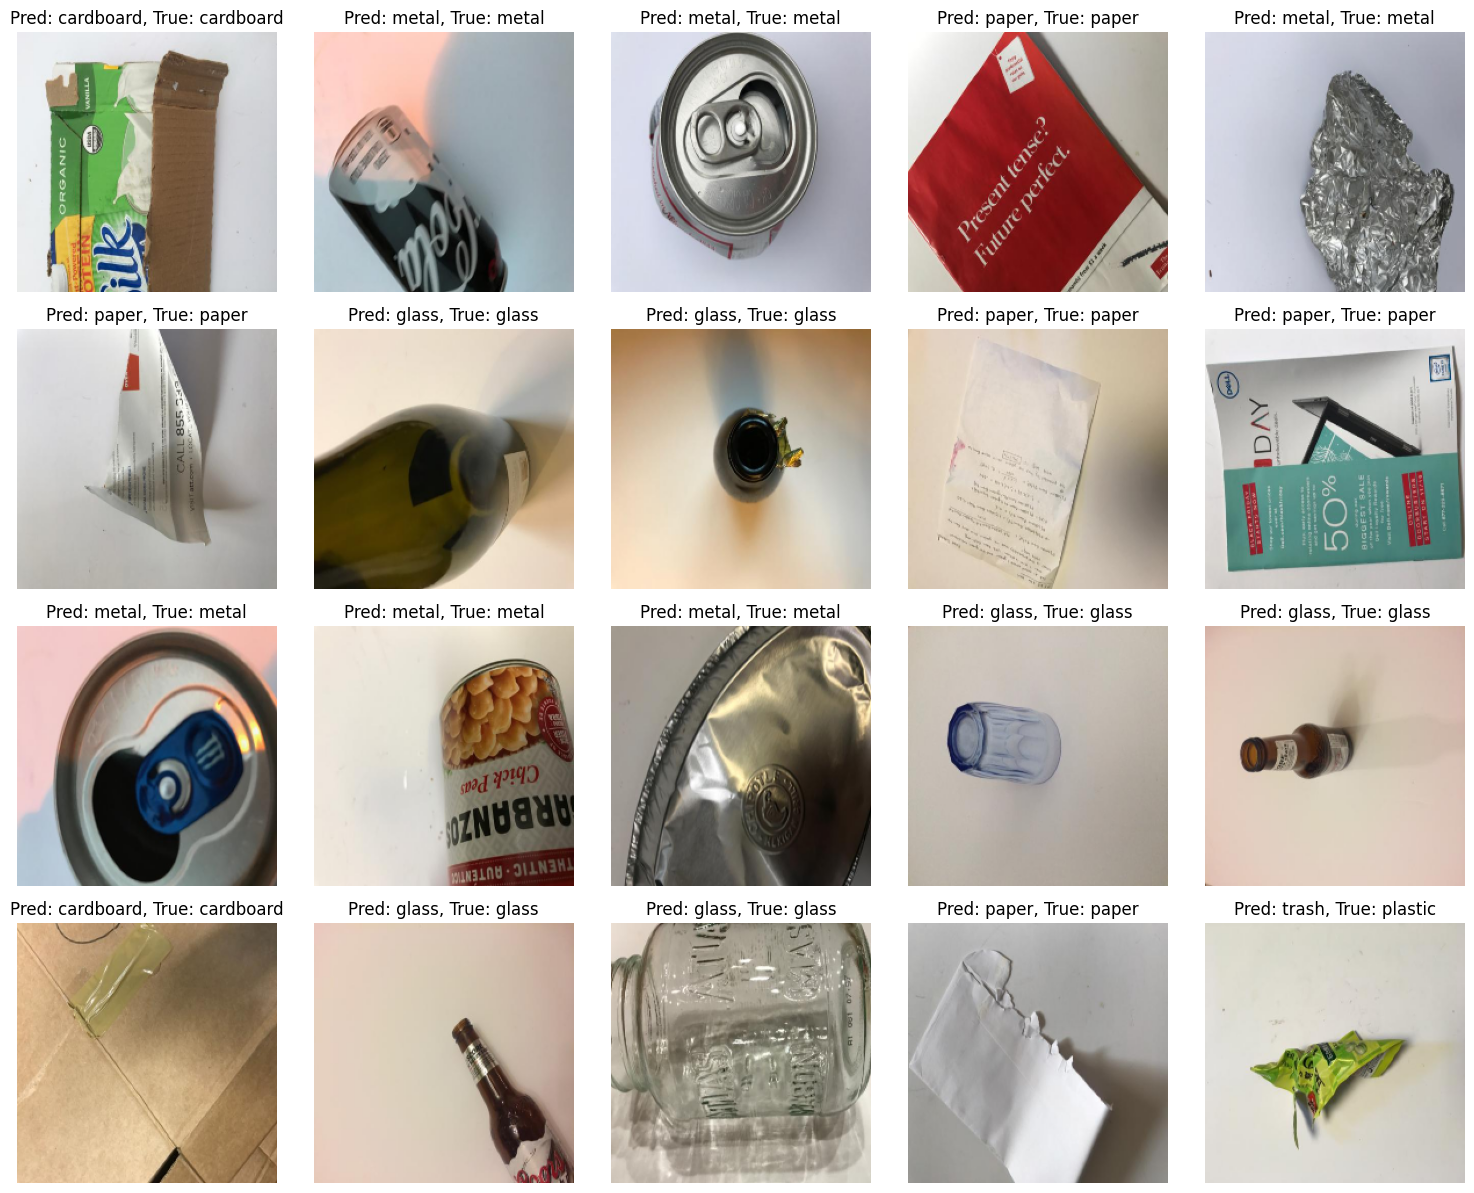

In [12]:
import matplotlib.pyplot as plt

# Visualize Predictions
def visualize_predictions(test_images, test_labels, predicted_labels, class_names, num_images=20):
    plt.figure(figsize=(15, 15))
    for i in range(num_images):
        ax = plt.subplot(5, 5, i + 1)
        img = test_images[i].astype("uint8")
        true_label = class_names[test_labels[i]]
        pred_label = class_names[predicted_labels[i]]
        plt.imshow(img)
        plt.title(f"Pred: {pred_label}, True: {true_label}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Use the first batch of test images
test_images, test_labels = next(test_gen)
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

# Class Names (based on dataset folders)
class_names = classes

# Visualize
visualize_predictions(test_images, test_labels, predicted_labels, class_names, num_images=20)


In [13]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Fungsi untuk memproses gambar input
def process_input_image(image_path, img_size=IMG_SIZE):
    img = load_img(image_path, target_size=(img_size, img_size))  # Muat dan ubah ukuran gambar
    img_array = img_to_array(img)  # Konversi ke array
    img_array = np.expand_dims(img_array, axis=0)  # Tambahkan dimensi batch
    img_array = preprocess_input(img_array)  # Preprocessing sesuai dengan EfficientNet
    return img_array

# Path ke gambar input Anda
input_image_path = "C:/Users/aqilw/OneDrive/Gambar/glass11.jpg"

# Proses gambar
input_image = process_input_image(input_image_path)

# Prediksi menggunakan model
prediction = model.predict(input_image)
predicted_label = np.argmax(prediction, axis=1)[0]

# Tampilkan hasil prediksi
print(f"Predicted Class: {classes[predicted_label]}")

1/1 [==============================] - 3s 3s/step
Predicted Class: glass


In [14]:
import pickle

with open("history_trial1.pkl", "wb") as f:
    pickle.dump(history.history, f)


In [16]:
# # 1. Simpan model
# model.save("best_model_trial1.keras")

# 2. Simpan bobot (optional)
model.save_weights("best_model_weights_trial1.keras")

# # 3. Simpan report sebagai JSON
# from sklearn.metrics import classification_report
# import json

# report = classification_report(test_labels, predicted_labels, output_dict=True)
# with open("eval_report_trial1.json", "w") as f:
#     json.dump(report, f, indent=4, default=str)  # <--- tambahkan default=str


In [ ]:
# model.summary()

In [ ]:
# from tensorflow.keras.utils import plot_model

# # Visualisasi struktur model
# plot_model(model, to_file='efficientnet_structure.png', show_shapes=True, show_layer_names=True)

In [ ]:
# # 2. Analisis Visualisasi Layer
# # Pilih beberapa layer dari EfficientNet untuk divisualisasikan
# layer_names = [layer.name for layer in base_model.layers if 'conv' in layer.name or 'pool' in layer.name]
# layer_outputs = [layer.output for layer in base_model.layers if 'conv' in layer.name or 'pool' in layer.name]

# # Model baru untuk visualisasi layer
# visualization_model = Model(inputs=base_model.input, outputs=layer_outputs)


In [ ]:
# # Pilih satu gambar dari dataset uji untuk divisualisasikan
# sample_image = preprocess_image(test_df['image_path'].iloc[0])
# sample_image = np.expand_dims(sample_image, axis=0)  # Tambahkan dimensi batch

# # Dapatkan output dari beberapa layer
# feature_maps = visualization_model.predict(sample_image)

# # Visualisasi beberapa feature maps
# for layer_name, feature_map in zip(layer_names, feature_maps):
#     if len(feature_map.shape) == 4:  # Jika feature map berbentuk (batch, height, width, channels)
#         num_channels = feature_map.shape[-1]
#         size = feature_map.shape[1]

#         plt.figure(figsize=(15, 15))
#         plt.suptitle(f"Feature Maps from Layer: {layer_name}")

#         # Plot beberapa channel pertama
#         for i in range(min(6, num_channels)):  # Batasi ke 6 channel pertama
#             plt.subplot(1, 6, i + 1)
#             plt.imshow(feature_map[0, :, :, i], cmap='viridis')
#             plt.axis('off')
#         plt.tight_layout()
#         plt.show()
